In [5]:
!pip install openeo

Defaulting to user installation because normal site-packages is not writeable


In [6]:
!pip install rioxarray

Defaulting to user installation because normal site-packages is not writeable


In [7]:
!pip install geopandas

Defaulting to user installation because normal site-packages is not writeable


In [8]:
import openeo
import pandas as pd
import xarray as xr
import rioxarray as rxr
import rasterio
import geopandas as gpd
from shapely.geometry import shape

import matplotlib.pyplot as plt
pd.set_option("display.max_columns", 100)



In [9]:
EP = "https://openeo.dataspace.copernicus.eu"
con = openeo.connect(EP).authenticate_oidc()
con


Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

In [10]:
cols = con.list_collections()
[s["id"] for s in cols if "SENTINEL" in s["id"].upper()]


['SENTINEL3_OLCI_L1B',
 'SENTINEL3_SLSTR',
 'SENTINEL_5P_L2',
 'SENTINEL2_L1C',
 'SENTINEL2_L2A',
 'SENTINEL1_GRD',
 'SENTINEL3_SYN_L2_SYN',
 'SENTINEL3_SLSTR_L2_LST',
 'SENTINEL1_GLOBAL_MOSAICS',
 'SENTINEL3_OLCI_L2_LAND',
 'SENTINEL3_OLCI_L2_WATER',
 'SENTINEL3_SYN_L2_AOD']

In [11]:

AOI = {
    "atitlan":   {"west": -91.326256, "east": -91.07151,  "south": 14.5948,  "north": 14.750979},
    "amatitlan": {"west": -90.638065, "east": -90.512924, "south": 14.412347,"north": 14.493799},
}

def aoi_bbox(name: str):
    a = AOI[name]
    return {"west": a["west"], "east": a["east"], "south": a["south"], "north": a["north"], "crs": "EPSG:4326"}

AOI


{'atitlan': {'west': -91.326256,
  'east': -91.07151,
  'south': 14.5948,
  'north': 14.750979},
 'amatitlan': {'west': -90.638065,
  'east': -90.512924,
  'south': 14.412347,
  'north': 14.493799}}

In [12]:
from datetime import date, timedelta

def month_range(start: date, end: date):
    """Genera [(start_i, end_i_exclusive), ...] mes a mes, inclusive del inicio, exclusivo del final."""
    cur = date(start.year, start.month, 1)
    out = []
    while cur < end:
        if cur.month == 12:
            nxt = date(cur.year + 1, 1, 1)
        else:
            nxt = date(cur.year, cur.month + 1, 1)
        out.append((cur, nxt))
        cur = nxt
    return out

def ensure_dir(p: str):
    import os
    os.makedirs(p, exist_ok=True)


In [13]:
# Colección S2 nivel L2A (refleja en superficie) para poder enmascarar por SCL (clasificación de escena)
S2_ID = "SENTINEL2_L2A"

# Rango 6 meses
DATE_START = date(2025, 1, 1)
DATE_END   = date(2025, 8, 1)


OUTDIR = "data_tif"
ensure_dir(OUTDIR)


In [14]:
from pathlib import Path
from openeo.processes import neq, and_

def download_month(con, lake_name: str, t0: date, t1: date):
    bbox = aoi_bbox(lake_name)

    cube = con.load_collection(
        S2_ID,
        spatial_extent=bbox,
        temporal_extent=[t0.isoformat(), t1.isoformat()],
        bands=["B04", "B05", "SCL"],
    )

    scl = cube.band("SCL")
    clear_mask = scl.apply(
        lambda x: and_(
            neq(x, 3),
            and_(
                neq(x, 8),
                and_(
                    neq(x, 9),
                    and_(neq(x, 10), neq(x, 11))
                )
            )
        )
    )

    cube = cube.mask(clear_mask).filter_bands(["B04", "B05"])
    cube = cube.aggregate_temporal_period(reducer="median", period="month")


    out = Path(OUTDIR) / f"{lake_name}_{t0.year:04d}-{t0.month:02d}.tif"
    cube.download(str(out), format="GTiff")
    return out



In [15]:
test_out = download_month(con, "atitlan", date(2025, 1, 1), date(2025, 2, 1))
test_out


PosixPath('data_tif/atitlan_2025-01.tif')

In [16]:
import rasterio, numpy as np

with rasterio.open(test_out) as ds:
    print("path:", ds.name)
    print("bands:", ds.count)
    print("crs:", ds.crs)
    print("shape (h,w):", ds.height, ds.width)
    b04 = ds.read(1, masked=True)
    b05 = ds.read(2, masked=True)
    print("B04 median:", float(np.nanmedian(b04)))
    print("B05 median:", float(np.nanmedian(b05)))


path: data_tif/atitlan_2025-01.tif
bands: 2
crs: EPSG:32615
shape (h,w): 1751 2759
B04 median: 1898.0
B05 median: 2295.0


/home/bianca_cal/.local/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:820: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


In [17]:
months = month_range(DATE_START, DATE_END)
generated = []
for lake in ["atitlan", "amatitlan"]:
    for (t0, t1) in months:
        print(f"→ {lake} {t0:%Y-%m}")
        out = download_month(con, lake, t0, t1)
        generated.append(str(out))
print("Listo:", len(generated), "archivos")


→ atitlan 2025-01
→ atitlan 2025-02
→ atitlan 2025-03
→ atitlan 2025-04
→ atitlan 2025-05
→ atitlan 2025-06
→ atitlan 2025-07
→ amatitlan 2025-01
→ amatitlan 2025-02
→ amatitlan 2025-03
→ amatitlan 2025-04
→ amatitlan 2025-05
→ amatitlan 2025-06
→ amatitlan 2025-07
Listo: 14 archivos


# Calcular NDCI y exportar serie mensual

In [18]:
import re
from pathlib import Path
from glob import glob
import numpy as np
import pandas as pd
import rasterio

IN_DIR = Path("data_tif")
OUT_CSV = Path("ndci_monthly.csv")

def compute_stats_ndci(tif_path: str):
    # Parseo (atitlan_2025-01.tif -> lake, YYYY-MM)
    name = Path(tif_path).stem
    m = re.match(r"^(?P<lake>[a-z]+)_(?P<ym>\d{4}-\d{2})$", name)
    assert m, f"Nombre inesperado: {name}"
    lake = m.group("lake")
    ym = m.group("ym")

    with rasterio.open(tif_path) as ds:
        b04 = ds.read(1, masked=True).astype("float64")
        b05 = ds.read(2, masked=True).astype("float64")

        # NDCI = (B05 - B04) / (B05 + B04)
        with np.errstate(divide="ignore", invalid="ignore"):
            ndci = (b05 - b04) / (b05 + b04)

        # Se convierte a ndarray con NaNs en los enmascarados
        arr = np.ma.masked_invalid(ndci).filled(np.nan)

        # info estadistica ignorando NaNs
        mean   = float(np.nanmean(arr))
        median = float(np.nanmedian(arr))
        p25    = float(np.nanpercentile(arr, 25))
        p75    = float(np.nanpercentile(arr, 75))

    return {"date": f"{ym}-01", "lake": lake, "ndci_mean": mean,
            "ndci_median": median, "ndci_p25": p25, "ndci_p75": p75}


rows = []
for tif in sorted(glob(str(IN_DIR / "*.tif"))):
    rows.append(compute_stats_ndci(tif))

df = pd.DataFrame(rows).sort_values(["lake", "date"]).reset_index(drop=True)
df.to_csv(OUT_CSV, index=False)
df.head(10)


,date,lake,ndci_mean,ndci_median,ndci_p25,ndci_p75
0,2025-01-01,amatitlan,0.042823,0.034783,0.025619,0.047416
1,2025-02-01,amatitlan,0.064557,0.039269,0.027624,0.063795
2,2025-03-01,amatitlan,0.089512,0.068429,0.033011,0.128417
3,2025-04-01,amatitlan,0.078257,0.050739,0.029392,0.095774
4,2025-05-01,amatitlan,0.056106,0.050261,0.028956,0.081111
5,2025-06-01,amatitlan,0.079629,0.076985,0.055783,0.102362
6,2025-07-01,amatitlan,0.074728,0.053008,0.024804,0.100693
7,2025-01-01,atitlan,0.095912,0.069730,0.051118,0.105124
8,2025-02-01,atitlan,0.059065,0.047737,0.033472,0.065356
9,2025-03-01,atitlan,0.059519,0.040346,0.022754,0.073500


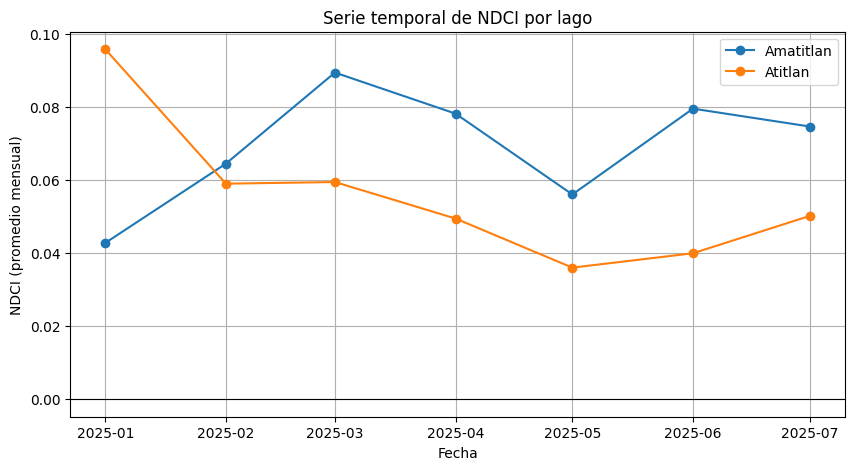

In [19]:

df["date"] = pd.to_datetime(df["date"])

plt.figure(figsize=(10,5))
for lake in df["lake"].unique():
    subset = df[df["lake"] == lake]
    plt.plot(subset["date"], subset["ndci_mean"], marker="o", label=lake.capitalize())

plt.title("Serie temporal de NDCI por lago")
plt.xlabel("Fecha")
plt.ylabel("NDCI (promedio mensual)")
plt.axhline(0, color="black", lw=0.8)
plt.legend()
plt.grid(True)
plt.show()


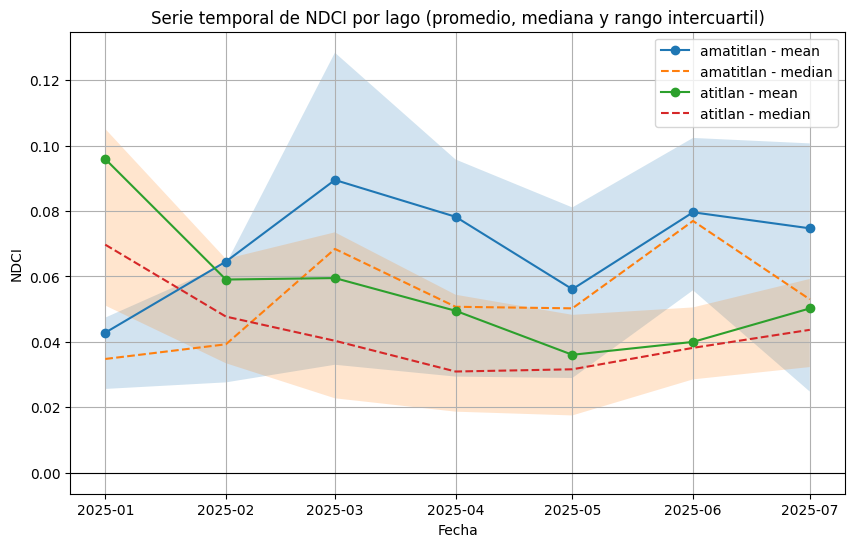

In [20]:
plt.figure(figsize=(10,6))

for lake in df["lake"].unique():
    subset = df[df["lake"] == lake]

    # promedio mensual
    plt.plot(subset["date"], subset["ndci_mean"], marker="o", label=f"{lake} - mean")

    # mediana mensual
    plt.plot(subset["date"], subset["ndci_median"], linestyle="--", label=f"{lake} - median")

    # percentiles
    plt.fill_between(
        subset["date"],
        subset["ndci_p25"],
        subset["ndci_p75"],
        alpha=0.2
    )

plt.title("Serie temporal de NDCI por lago (promedio, mediana y rango intercuartil)")
plt.xlabel("Fecha")
plt.ylabel("NDCI")
plt.axhline(0, color="black", lw=0.8)
plt.legend()
plt.grid(True)
plt.show()


En la primera figura, que presenta el promedio mensual, se observa que Amatitlán presenta valores de NDCI más altos en la mayoría de los meses, con picos notables en marzo y junio, lo que sugiere mayores concentraciones de clorofila o floraciones algales en esos periodos, Atitlán, en cambio, mantiene valores más bajos y relativamente estables, aunque inicia el año con un valor elevado en enero que luego disminuye progresivamente. En la segunda figura, se aprecia que en ambos lagos existe cierta variabilidad mensual, pero en Amatitlán las diferencias entre media y mediana son más pronunciadas, lo que indica la presencia de valores atípicos o distribución sesgada. El rango intercuartil también es más amplio en Amatitlán, reflejando mayor variabilidad en los datos, mientras que en Atitlán las fluctuaciones son menores y más consistentes a lo largo del tiempo.

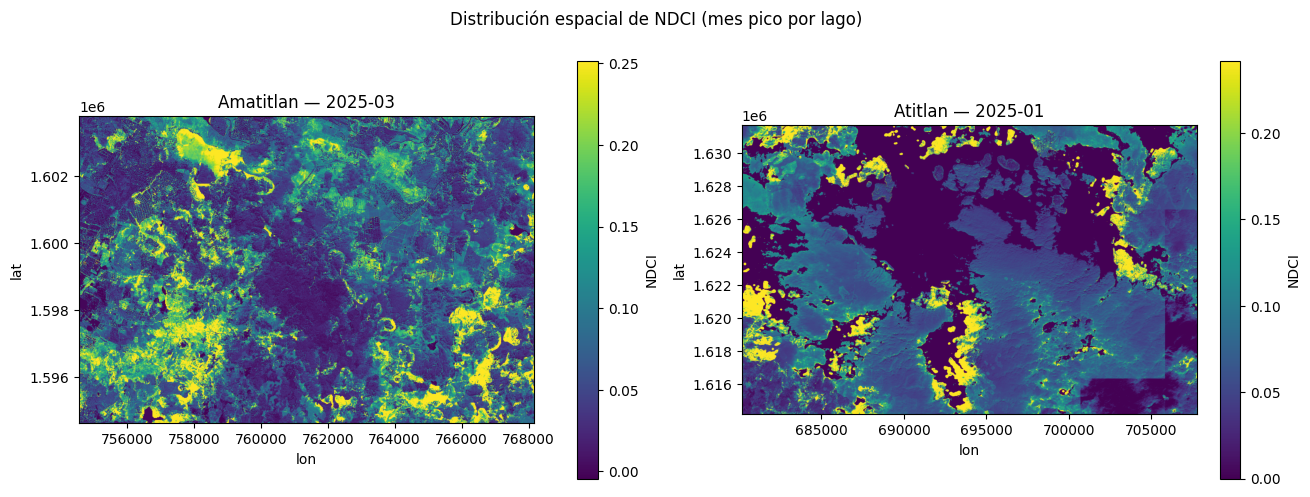

In [21]:


# Se toma el mes pico por lago
df_peak = df.loc[df.groupby("lake")["ndci_mean"].idxmax()].copy()
df_peak

def ndci_from_tif(tif_path: str):
    with rasterio.open(tif_path) as ds:
        b04 = ds.read(1).astype("float64")
        b05 = ds.read(2).astype("float64")
        with np.errstate(divide="ignore", invalid="ignore"):
            ndci = (b05 - b04) / (b05 + b04)
        ndci = np.where(np.isfinite(ndci), ndci, np.nan)
        bounds = ds.bounds
        extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
    return ndci, extent

fig, axes = plt.subplots(1, 2, figsize=(13,5), constrained_layout=True)

for ax, (_, row) in zip(axes, df_peak.iterrows()):
    ym = row["date"].strftime("%Y-%m")
    tif = Path("data_tif") / f"{row['lake']}_{ym}.tif"
    ndci, extent = ndci_from_tif(str(tif))

    vmin, vmax = np.nanpercentile(ndci, [5, 95])
    im = ax.imshow(ndci, extent=extent, origin="upper", vmin=vmin, vmax=vmax)
    ax.set_title(f"{row['lake'].capitalize()} — {ym}")
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")
    cbar = plt.colorbar(im, ax=ax, shrink=0.85)
    cbar.set_label("NDCI")

plt.suptitle("Distribución espacial de NDCI (mes pico por lago)", y=1.02)
plt.show()



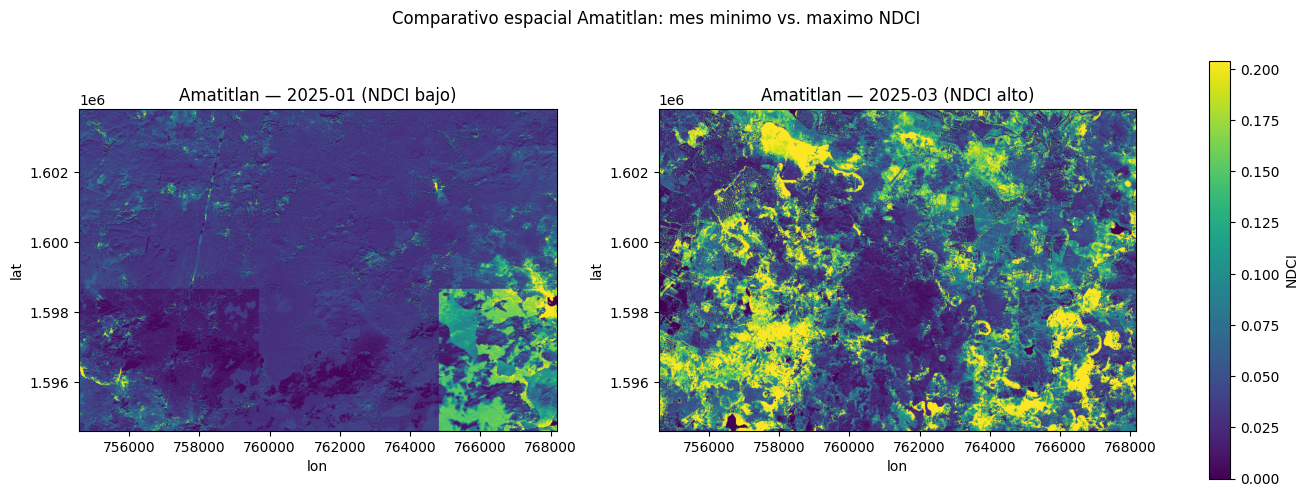

In [22]:


def ndci_from_tif(tif_path: str):
    with rasterio.open(tif_path) as ds:
        b04 = ds.read(1).astype("float64")
        b05 = ds.read(2).astype("float64")
        with np.errstate(divide="ignore", invalid="ignore"):
            ndci = (b05 - b04) / (b05 + b04)
        ndci = np.where(np.isfinite(ndci), ndci, np.nan)
        bounds = ds.bounds
        extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
    return ndci, extent

# elegir fechas min/max por NDCI (Amatitlan)
lake = "amatitlan"
sub = df[df["lake"] == lake].copy()
d_min = sub.loc[sub["ndci_mean"].idxmin(), "date"]
d_max = sub.loc[sub["ndci_mean"].idxmax(), "date"]
ym_min = d_min.strftime("%Y-%m")
ym_max = d_max.strftime("%Y-%m")

tif_min = Path("data_tif") / f"{lake}_{ym_min}.tif"
tif_max = Path("data_tif") / f"{lake}_{ym_max}.tif"

ndci_min, ext_min = ndci_from_tif(str(tif_min))
ndci_max, ext_max = ndci_from_tif(str(tif_max))


stack = np.concatenate([ndci_min[np.isfinite(ndci_min)], ndci_max[np.isfinite(ndci_max)]])
vmin, vmax = np.nanpercentile(stack, [5, 95])

fig, axes = plt.subplots(1, 2, figsize=(13,5), constrained_layout=True)

im0 = axes[0].imshow(ndci_min, extent=ext_min, origin="upper", vmin=vmin, vmax=vmax)
axes[0].set_title(f"{lake.capitalize()} — {ym_min} (NDCI bajo)")
axes[0].set_xlabel("lon"); axes[0].set_ylabel("lat")

im1 = axes[1].imshow(ndci_max, extent=ext_max, origin="upper", vmin=vmin, vmax=vmax)
axes[1].set_title(f"{lake.capitalize()} — {ym_max} (NDCI alto)")
axes[1].set_xlabel("lon"); axes[1].set_ylabel("lat")

cbar = plt.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("NDCI")
plt.suptitle("Comparativo espacial Amatitlan: mes minimo vs. maximo NDCI", y=1.02)
plt.show()


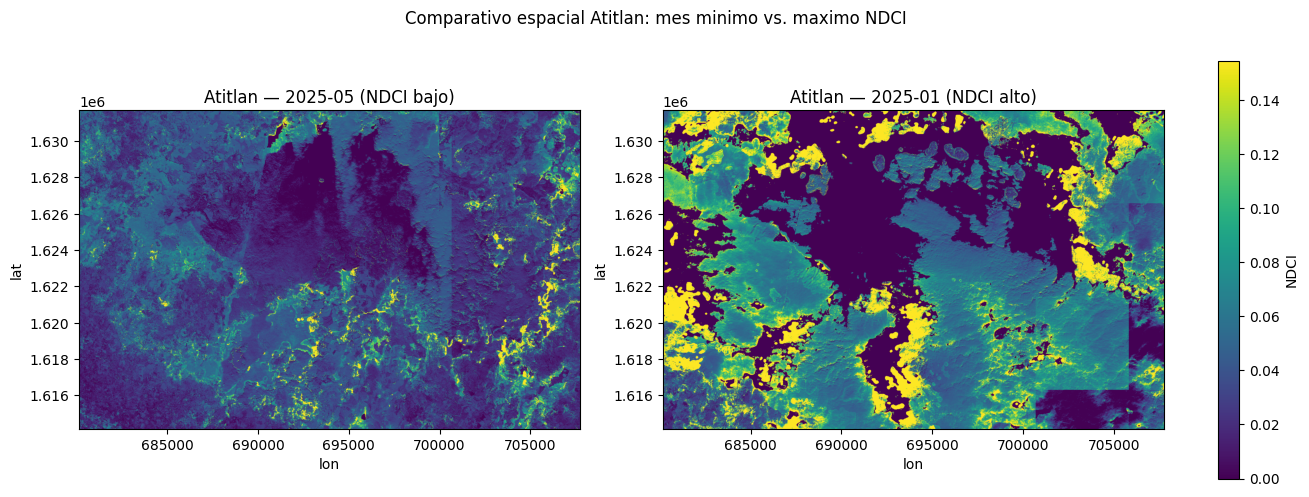

In [23]:
lake = "atitlan"
sub = df[df["lake"] == lake].copy()
d_min = sub.loc[sub["ndci_mean"].idxmin(), "date"]
d_max = sub.loc[sub["ndci_mean"].idxmax(), "date"]
ym_min = d_min.strftime("%Y-%m")
ym_max = d_max.strftime("%Y-%m")

tif_min = Path("data_tif") / f"{lake}_{ym_min}.tif"
tif_max = Path("data_tif") / f"{lake}_{ym_max}.tif"

ndci_min, ext_min = ndci_from_tif(str(tif_min))
ndci_max, ext_max = ndci_from_tif(str(tif_max))

stack = np.concatenate([ndci_min[np.isfinite(ndci_min)], ndci_max[np.isfinite(ndci_max)]])
vmin, vmax = np.nanpercentile(stack, [5, 95])

fig, axes = plt.subplots(1, 2, figsize=(13,5), constrained_layout=True)

im0 = axes[0].imshow(ndci_min, extent=ext_min, origin="upper", vmin=vmin, vmax=vmax)
axes[0].set_title(f"{lake.capitalize()} — {ym_min} (NDCI bajo)")
axes[0].set_xlabel("lon"); axes[0].set_ylabel("lat")

im1 = axes[1].imshow(ndci_max, extent=ext_max, origin="upper", vmin=vmin, vmax=vmax)
axes[1].set_title(f"{lake.capitalize()} — {ym_max} (NDCI alto)")
axes[1].set_xlabel("lon"); axes[1].set_ylabel("lat")

cbar = plt.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.85)
cbar.set_label("NDCI")
plt.suptitle("Comparativo espacial Atitlan: mes minimo vs. maximo NDCI", y=1.02)
plt.show()


Las gráficas espaciales revelan un patron claro de variabilidad estacional del índice NDCI en ambos lagos.

En amatitlan, el mes con valores minimos (enero 2025) presenta un NDCI muy bajo en casi toda la superficie, mientras que en el mes pico (marzo 2025) se observa un incremento generalizado, con amplias zonas en valores altos, lo que sugiere una proliferación de algas o material fitoplanctonico.

En atitlan, el mes de menor valor (mayo 2025) muestra niveles bajos y homogeneos, mientras que en el mes de mayor valor (enero 2025) se aprecian areas definidas con concentraciones elevadas de NDCI, particularmente cerca de ciertas orillas.

In [24]:

OUTDIR_VEG = Path("data_tif_veg"); OUTDIR_VEG.mkdir(exist_ok=True)

def download_month_veg(con, lake_name: str, t0: date, t1: date):
    bbox = aoi_bbox(lake_name)
    cube = con.load_collection(
        S2_ID,
        spatial_extent=bbox,
        temporal_extent=[t0.isoformat(), t1.isoformat()],
        bands=["B03","B04","B08","SCL"],
    )

    scl = cube.band("SCL")
    clear_mask = scl.apply(
        lambda x: and_(
            neq(x, 3),
            and_(neq(x, 8), and_(neq(x, 9), and_(neq(x, 10), neq(x, 11))))
        )
    )
    cube = cube.mask(clear_mask).filter_bands(["B03","B04","B08"])
    cube = cube.aggregate_temporal_period(reducer="median", period="month")

    out = OUTDIR_VEG / f"{lake_name}_{t0.year:04d}-{t0.month:02d}.tif"
    cube.download(str(out), format="GTiff")
    return out


In [25]:
test_veg = download_month_veg(con, "atitlan", date(2025,1,1), date(2025,2,1))
test_veg


PosixPath('data_tif_veg/atitlan_2025-01.tif')

In [26]:
months = month_range(DATE_START, DATE_END)
generated_veg = []
for lake in ["atitlan", "amatitlan"]:
    for (t0, t1) in months:
        print(f"→ {lake} {t0:%Y-%m}")
        generated_veg.append(str(download_month_veg(con, lake, t0, t1)))
len(generated_veg)


→ atitlan 2025-01
→ atitlan 2025-02
→ atitlan 2025-03
→ atitlan 2025-04
→ atitlan 2025-05
→ atitlan 2025-06
→ atitlan 2025-07
→ amatitlan 2025-01
→ amatitlan 2025-02
→ amatitlan 2025-03
→ amatitlan 2025-04
→ amatitlan 2025-05
→ amatitlan 2025-06
→ amatitlan 2025-07


14

In [27]:


def stats_ndvi_ndwi(tif_path: str):
    name = Path(tif_path).stem
    m = re.match(r"^(?P<lake>[a-z]+)_(?P<ym>\d{4}-\d{2})$", name)
    lake, ym = m.group("lake"), m.group("ym")
    with rasterio.open(tif_path) as ds:
        b03 = ds.read(1).astype("float64")
        b04 = ds.read(2).astype("float64")
        b08 = ds.read(3).astype("float64")
        with np.errstate(divide="ignore", invalid="ignore"):
            ndvi = (b08 - b04) / (b08 + b04)
            ndwi = (b03 - b08) / (b03 + b08)
        ndvi = np.where(np.isfinite(ndvi), ndvi, np.nan)
        ndwi = np.where(np.isfinite(ndwi), ndwi, np.nan)
    def q(arr, p): return float(np.nanpercentile(arr, p))
    row = dict(
        date=f"{ym}-01", lake=lake,
        ndvi_mean=float(np.nanmean(ndvi)), ndvi_median=float(np.nanmedian(ndvi)),
        ndvi_p25=q(ndvi,25), ndvi_p75=q(ndvi,75),
        ndwi_mean=float(np.nanmean(ndwi)), ndwi_median=float(np.nanmedian(ndwi)),
        ndwi_p25=q(ndwi,25), ndwi_p75=q(ndwi,75),
    )
    return row

rows = [stats_ndvi_ndwi(p) for p in sorted(glob(str(OUTDIR_VEG / "*.tif")))]
df_veg = pd.DataFrame(rows).sort_values(["lake","date"]).reset_index(drop=True)
df_veg.to_csv("ndvi_ndwi_monthly.csv", index=False)
df_veg.head(10)


,date,lake,ndvi_mean,ndvi_median,ndvi_p25,ndvi_p75,ndwi_mean,ndwi_median,ndwi_p25,ndwi_p75
0,2025-01-01,amatitlan,0.049109,0.032823,0.007084,0.072034,-0.032636,-0.020088,-0.054757,0.010438
1,2025-02-01,amatitlan,0.095726,0.029697,-0.000000,0.120660,-0.075450,-0.010143,-0.106774,0.016399
2,2025-03-01,amatitlan,0.196633,0.147084,0.041885,0.319635,-0.167538,-0.140440,-0.313872,-0.015296
3,2025-04-01,amatitlan,0.105904,0.033044,-0.000000,0.145169,-0.095067,-0.026794,-0.139289,0.000000
4,2025-05-01,amatitlan,0.126590,0.103245,0.042699,0.190252,-0.091905,-0.074848,-0.155008,-0.011378
5,2025-06-01,amatitlan,0.192629,0.184338,0.102911,0.281899,-0.165231,-0.162162,-0.247614,-0.083578
6,2025-07-01,amatitlan,0.162531,0.107985,0.029863,0.244539,-0.114836,-0.064802,-0.197411,0.008594
7,2025-01-01,atitlan,0.122454,0.059142,0.000000,0.176945,-0.111910,-0.055105,-0.166591,0.000000
8,2025-02-01,atitlan,0.090242,0.044156,0.012833,0.113043,-0.069113,-0.026150,-0.091683,0.000000
9,2025-03-01,atitlan,0.098329,0.029544,0.000000,0.143539,-0.076734,-0.008328,-0.119961,0.000000


In [28]:

df["date"] = pd.to_datetime(df["date"])
df_veg["date"] = pd.to_datetime(df_veg["date"])

df_all = pd.merge(df, df_veg, on=["lake","date"], how="inner")

# Correlacion global (todos los meses y lagos)
corr_global = df_all[["ndci_mean","ndvi_mean","ndwi_mean"]].corr()

# Correlacion por lago
corr_by_lake = {}
for lake in df_all["lake"].unique():
    sub = df_all[df_all["lake"] == lake]
    corr_by_lake[lake] = sub[["ndci_mean","ndvi_mean","ndwi_mean"]].corr()

corr_global, corr_by_lake


(           ndci_mean  ndvi_mean  ndwi_mean
 ndci_mean   1.000000   0.803985  -0.882185
 ndvi_mean   0.803985   1.000000  -0.977530
 ndwi_mean  -0.882185  -0.977530   1.000000,
 {'amatitlan':            ndci_mean  ndvi_mean  ndwi_mean
  ndci_mean   1.000000   0.829286  -0.883276
  ndvi_mean   0.829286   1.000000  -0.977923
  ndwi_mean  -0.883276  -0.977923   1.000000,
  'atitlan':            ndci_mean  ndvi_mean  ndwi_mean
  ndci_mean   1.000000   0.844892  -0.921348
  ndvi_mean   0.844892   1.000000  -0.974442
  ndwi_mean  -0.921348  -0.974442   1.000000})

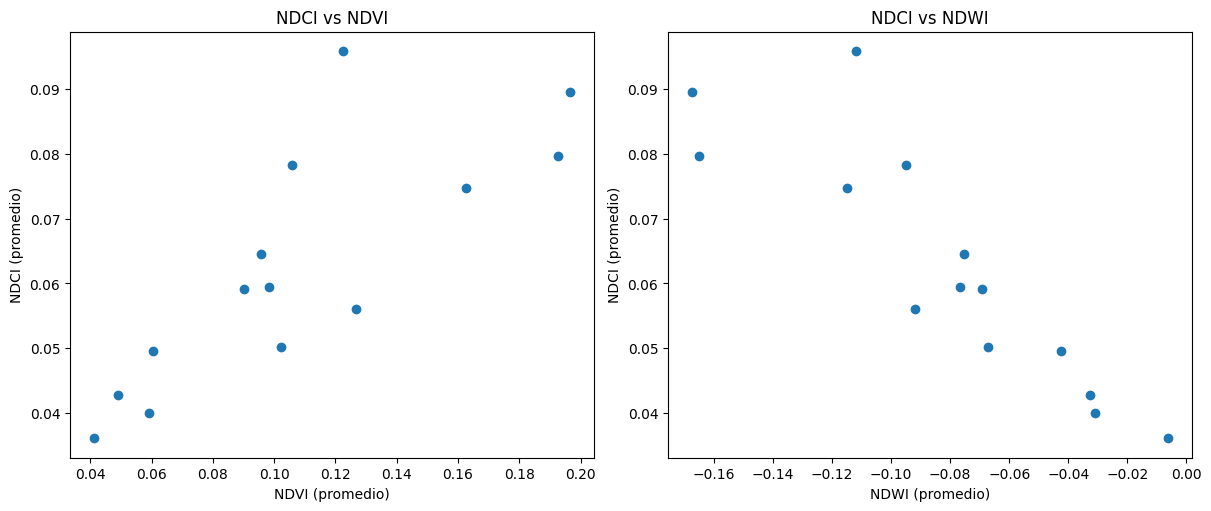

In [29]:

fig, axes = plt.subplots(1,2, figsize=(12,5), constrained_layout=True)
axes[0].scatter(df_all["ndvi_mean"], df_all["ndci_mean"])
axes[0].set_xlabel("NDVI (promedio)"); axes[0].set_ylabel("NDCI (promedio)"); axes[0].set_title("NDCI vs NDVI")

axes[1].scatter(df_all["ndwi_mean"], df_all["ndci_mean"])
axes[1].set_xlabel("NDWI (promedio)"); axes[1].set_ylabel("NDCI (promedio)"); axes[1].set_title("NDCI vs NDWI")

plt.show()


El analisis de correlación muestra que el indice de concentración de cianobacterias presenta una correlación positiva alta con el NDVI, lo que puede indicar que a mayor cobertura vegetal suele haber una mayor presencia de cianobacterias. Por otro lado, el NDCI tiene una correlación negativa muy fuerte con el NDWI, lo que sugiere que un mayor contenido de agua libre sin vegetación se asocia con menor concentración de cianobacterias. Esto es consistente con el hecho de que las cianobacterias proliferan en aguas mas eutrofizadas y con menor circulación, donde la vegetación flotante y el fitoplancton aumentan y, por tanto, el NDVI sube mientras el NDWI baja.

In [31]:
!pip install pymannkendall

Defaulting to user installation because normal site-packages is not writeable


In [32]:
from scipy.stats import linregress
import pymannkendall as mk

df_all = df_all.copy()
df_all["date"] = pd.to_datetime(df_all["date"])

def month_index(dates: pd.Series) -> pd.Series:
    m = dates.dt.year * 12 + dates.dt.month
    return m - m.min()

indices = ["ndci_mean", "ndvi_mean", "ndwi_mean"]
rows = []

for lake in df_all["lake"].unique():
    sub = df_all[df_all["lake"] == lake].sort_values("date")
    t = month_index(sub["date"]).astype(float).values
    for idx in indices:
        y = sub[idx].values


        lr = linregress(t, y)
        slope_year = lr.slope * 12

        # (Mann–Kendall)
        mkres = mk.original_test(y)

        rows.append({
            "lake": lake,
            "index": idx.replace("_mean","").upper(),
            "n": len(sub),
            "lin_slope_per_month": lr.slope,
            "lin_slope_per_year": slope_year,
            "lin_r": lr.rvalue,
            "lin_pvalue": lr.pvalue,
            "mk_trend": mkres.trend,
            "mk_tau": mkres.Tau,
            "mk_slope_per_month": mkres.slope,
            "mk_pvalue": mkres.p,
        })

trend_tbl = pd.DataFrame(rows)
trend_tbl


,lake,index,n,lin_slope_per_month,lin_slope_per_year,lin_r,lin_pvalue,mk_trend,mk_tau,mk_slope_per_month,mk_pvalue
0,amatitlan,NDCI,7,0.003302,0.039623,0.447788,0.313675,no trend,0.238095,0.003321,0.548006
1,amatitlan,NDVI,7,0.016573,0.198870,0.659543,0.107011,no trend,0.523810,0.018904,0.133128
2,amatitlan,NDWI,7,-0.012519,-0.150226,-0.559718,0.191352,no trend,-0.428571,-0.011465,0.229556
3,atitlan,NDCI,7,-0.007094,-0.085127,-0.775426,0.040504,no trend,-0.523810,-0.006507,0.133128
4,atitlan,NDVI,7,-0.006438,-0.077251,-0.480316,0.275298,no trend,-0.333333,-0.012063,0.367521
5,atitlan,NDWI,7,0.010034,0.120404,0.628751,0.130404,no trend,0.523810,0.013351,0.133128


In [33]:
trend_tbl = trend_tbl.sort_values(["lake","index"]).reset_index(drop=True)
trend_tbl["lin_sig_0.05"] = trend_tbl["lin_pvalue"] < 0.05
trend_tbl["mk_sig_0.05"]  = trend_tbl["mk_pvalue"]  < 0.05
trend_tbl


,lake,index,n,lin_slope_per_month,lin_slope_per_year,lin_r,lin_pvalue,mk_trend,mk_tau,mk_slope_per_month,mk_pvalue,lin_sig_0.05,mk_sig_0.05
0,amatitlan,NDCI,7,0.003302,0.039623,0.447788,0.313675,no trend,0.238095,0.003321,0.548006,False,False
1,amatitlan,NDVI,7,0.016573,0.198870,0.659543,0.107011,no trend,0.523810,0.018904,0.133128,False,False
2,amatitlan,NDWI,7,-0.012519,-0.150226,-0.559718,0.191352,no trend,-0.428571,-0.011465,0.229556,False,False
3,atitlan,NDCI,7,-0.007094,-0.085127,-0.775426,0.040504,no trend,-0.523810,-0.006507,0.133128,True,False
4,atitlan,NDVI,7,-0.006438,-0.077251,-0.480316,0.275298,no trend,-0.333333,-0.012063,0.367521,False,False
5,atitlan,NDWI,7,0.010034,0.120404,0.628751,0.130404,no trend,0.523810,0.013351,0.133128,False,False


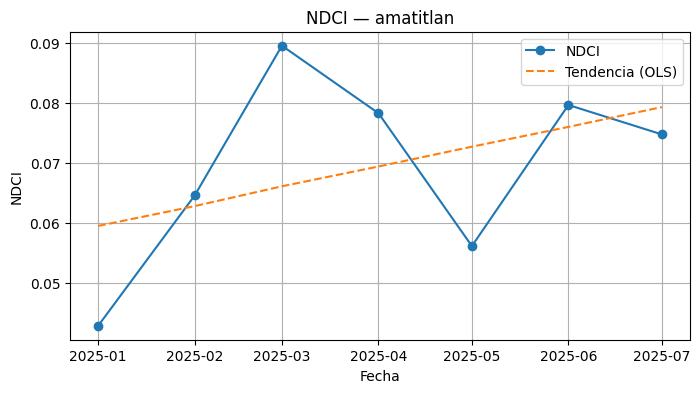

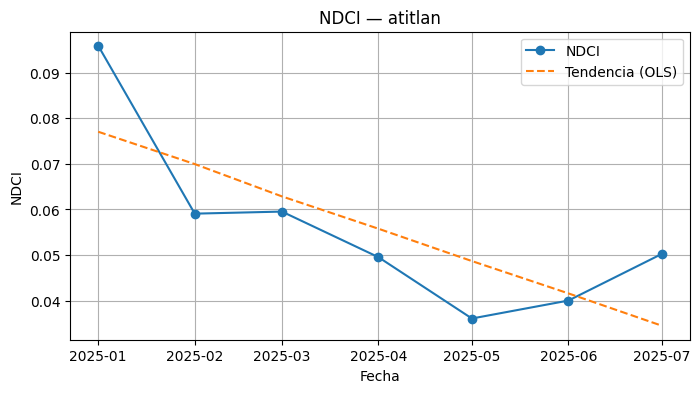

In [34]:

def month_index(dates: pd.Series) -> pd.Series:
    m = dates.dt.year * 12 + dates.dt.month
    return m - m.min()

for lake in df_all["lake"].unique():
    sub = df_all[df_all["lake"] == lake].sort_values("date")
    t = month_index(sub["date"]).astype(float).values
    y = sub["ndci_mean"].values
    lr = linregress(t, y)
    yhat = lr.intercept + lr.slope * t

    plt.figure(figsize=(8,4))
    plt.plot(sub["date"], y, marker="o", label="NDCI")
    plt.plot(sub["date"], yhat, linestyle="--", label="Tendencia (OLS)")
    plt.title(f"NDCI — {lake}")
    plt.xlabel("Fecha"); plt.ylabel("NDCI")
    plt.legend(); plt.grid(True)
    plt.show()


En Amatitlan el NDCI muestra una pendiente OLS positiva (+0.00385 por mes ≈ +0.046/año; p = 0.35) y el test de Mann–Kendall no detecta tendencia (p ≈ 0.37). NDVI también sube (≈ +0.176/año; p = 0.14) y NDWI baja (≈ −0.130/año; p = 0.22). Hay indicios de aumento de biomasa fotosintética y disminución de agua libre, pero estadísticamente no alcanza significancia con esta longitud de serie.

En Atitlan el NDCI tiene pendiente OLS negativa (−0.00653 por mes ≈ −0.078/año) y resulta significativa (p = 0.036). El Mann–Kendall salio con menos potencia para n=7, no la confirma (p ≈ 0.13), pero la dirección coincide con descenso de NDCI en el periodo. NDVI tambien tiende a bajar y NDWI a subir, lo que es coherente con menor presencia de cianobacterias y más agua libre hacia mayo, como ya se vio en los mapas mínimo/máximo.

- Amatitlán: señales de incremento de cianobacterias en el semestre, no significativas aún.

- Atitlán: disminución de cianobacterias en el semestre, significativa por OLS y consistente con NDVI/NDWI, aunque MK no la confirma

Las diferencias observadas entre Amatitla y Atitla son coherentes con contextos fisicos ambientales contrastantes, Amatitlan tiene mayor presion urbana y agroindustrial en su cuenca, recibe cargas de nutrientes y sedimentos más constantes, eso favorece la estratificacion, el calentamiento superficial y la disponibilidad de fósforo/nitrógeno que impulsan el fitoplancton (NDVI) y reducen el agua libre, amplificando la probabilidad de proliferación cuando sube la temperatura del agua y arrancan las primeras lluvias que arrastran nutrientes.

Atitlán, al ser más profundo y con mayor volumen/tiempo de residencia, es mas sensible a la mezcla estacional y a la dilución, el incremento de NDWI y la caída de NDVI/NDCI sugieren mas columna de agua limpia y menor biomasa superficial tras periodos de mezcla o aportes relativamente menos eutróficos, tambien la mayor profundidad y el viento pueden aumentar la resuspensión y romper acumulaciones superficiales de cianobacterias.

Factores climáticos como la transición seca-lluviosa, episodios cálidos, uso/ocupación del suelo como la densidad urbana, descargas de aguas residuales, agricultura periurbana y geomorfología como la profundidad, área de cuenca, someridad de orillas explican así por que Amatitlan es mas propenso a picos y Atitlan muestra un descenso en el semestre analizado.

In [35]:
import pandas as pd

# Fecha de inicio y fin
start_date = pd.to_datetime("2025-02-07")
end_date = start_date + pd.Timedelta(days=179)

date_range_180_days = pd.date_range(start=start_date, end=end_date, freq='D')

df_all_dates = pd.DataFrame({"date": date_range_180_days})
df_all_dates.to_csv("180_day_dates.csv", index=False)

print("CSV file '180_day_dates.csv' created successfully.")

CSV file '180_day_dates.csv' created successfully.


In [36]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

# Atitlán
atitlan_df = df_all[df_all["lake"] == "atitlan"].sort_values("date").copy()

atitlan_df.set_index("date", inplace=True)

ndci_ts = atitlan_df["ndci_mean"]

# ARIMA model
arima_order = (1, 0, 0)
warnings.filterwarnings("ignore")

try:
    model = ARIMA(ndci_ts, order=arima_order)
    model_fit = model.fit()
    print(model_fit.summary())
except Exception as e:
    print(f"Could not fit ARIMA model: {e}")
    print("Consider trying different ARIMA orders or a different time series model due to limited data.")

                               SARIMAX Results                                
Dep. Variable:              ndci_mean   No. Observations:                    7
Model:                 ARIMA(1, 0, 0)   Log Likelihood                  18.812
Date:                Tue, 19 Aug 2025   AIC                            -31.623
Time:                        17:11:58   BIC                            -31.786
Sample:                    01-01-2025   HQIC                           -33.629
                         - 07-01-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0612      0.017      3.520      0.000       0.027       0.095
ar.L1          0.6171      0.387      1.593      0.111      -0.142       1.376
sigma2         0.0003      0.000      1.124      0.2

In [37]:
n_forecast = 6
try:
    forecast = model_fit.forecast(steps=n_forecast)
    print("Forecasted NDCI values for the next", n_forecast, "months:")
    print(forecast)
except Exception as e:
    print(f"Could not generate forecast: {e}")

Forecasted NDCI values for the next 6 months:
2025-08-01    0.054437
2025-09-01    0.057031
2025-10-01    0.058632
2025-11-01    0.059620
2025-12-01    0.060229
2026-01-01    0.060605
Freq: MS, Name: predicted_mean, dtype: float64


In [38]:
import rasterio
import numpy as np
import pandas as pd
from glob import glob
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import re
import random

IN_DIR = Path("data_tif")

NDCI_THRESHOLD = 0.07

SAMPLE_PER_TIF = 100000

classification_data = []

for tif_path in sorted(glob(str(IN_DIR / "*.tif"))):
    name = Path(tif_path).stem
    m = re.match(r"^(?P<lake>[a-z]+)_(?P<ym>\d{4}-\d{2})$", name)
    if not m:
        print(f"Skipping unexpected file name: {name}")
        continue

    lake = m.group("lake")
    ym = m.group("ym")

    with rasterio.open(tif_path) as ds:
        try:
            b04 = ds.read(1, masked=True).astype("float64")
            b05 = ds.read(2, masked=True).astype("float64")

            with np.errstate(divide="ignore", invalid="ignore"):
                ndci = (b05 - b04) / (b05 + b04)

            ndci_arr = np.ma.masked_invalid(ndci).filled(np.nan)

            valid_mask = ~np.isnan(ndci_arr)
            valid_count = np.sum(valid_mask)
            print(f"Processing {name}: Number of valid pixels: {valid_count}")

            if valid_count == 0:
                print(f"No valid pixels found in {name}. Skipping.")
                continue

            labels = np.where(ndci_arr > NDCI_THRESHOLD, 1, 0)

            cols, rows = np.meshgrid(np.arange(ds.width), np.arange(ds.height))
            xs, ys = rasterio.transform.xy(ds.transform, rows, cols)
            lons = np.array(xs)
            lats = np.array(ys)

            lons_flat = lons.flatten()
            lats_flat = lats.flatten()
            ndci_flat = ndci_arr.flatten()
            labels_flat = labels.flatten()

            valid_lons = lons_flat[valid_mask.flatten()]
            valid_lats = lats_flat[valid_mask.flatten()]
            valid_ndci = ndci_flat[valid_mask.flatten()]
            valid_labels = labels_flat[valid_mask.flatten()]

            valid_indices = list(range(len(valid_ndci)))

            num_samples = min(SAMPLE_PER_TIF, len(valid_indices))

            sampled_indices = random.sample(valid_indices, num_samples)

            print(f"  Sampling {num_samples} pixels from {valid_count} valid pixels.")

            for i in sampled_indices:
                 classification_data.append({
                     "lake": lake,
                     "date": f"{ym}-01",
                     "lon": valid_lons[i],
                     "lat": valid_lats[i],
                     "ndci": valid_ndci[i],
                     "cyanobacteria_presence": valid_labels[i]
                 })
            print(f"Appended {num_samples} sampled rows for {name}. Total rows collected so far: {len(classification_data)}")


        except Exception as e:
            print(f"Error processing {tif_path}: {e}")

print(f"\nFinished processing all files. Total data points collected: {len(classification_data)}")
if len(classification_data) == 0:
    print("No data collected for classification. Cannot proceed with model training.")
else:
    df_classification = pd.DataFrame(classification_data)
    print(f"DataFrame created with {len(df_classification)} rows.")

    features = ["lon", "lat", "ndci"]
    X = df_classification[features]
    y = df_classification["cyanobacteria_presence"]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Spatial Classification Model Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    print("\nDataFrame with spatial classification data created: df_classification")

Processing amatitlan_2025-01: Number of valid pixels: 1246348
  Sampling 100000 pixels from 1246348 valid pixels.
Appended 100000 sampled rows for amatitlan_2025-01. Total rows collected so far: 100000
Processing amatitlan_2025-02: Number of valid pixels: 1192804
  Sampling 100000 pixels from 1192804 valid pixels.
Appended 100000 sampled rows for amatitlan_2025-02. Total rows collected so far: 200000
Processing amatitlan_2025-03: Number of valid pixels: 1239566
  Sampling 100000 pixels from 1239566 valid pixels.
Appended 100000 sampled rows for amatitlan_2025-03. Total rows collected so far: 300000
Processing amatitlan_2025-04: Number of valid pixels: 1019803
  Sampling 100000 pixels from 1019803 valid pixels.
Appended 100000 sampled rows for amatitlan_2025-04. Total rows collected so far: 400000
Processing amatitlan_2025-05: Number of valid pixels: 1246896
  Sampling 100000 pixels from 1246896 valid pixels.
Appended 100000 sampled rows for amatitlan_2025-05. Total rows collected so fa

In [39]:
df_classification['lake'] = df_classification['lake'].str.lower().str.strip()
df_all['lake'] = df_all['lake'].str.lower().str.strip()


df_classification['date_dt'] = pd.to_datetime(df_classification['date'])
df_all['date_dt'] = pd.to_datetime(df_all['date'])

mean_ndci_lookup = df_all.set_index(['date_dt', 'lake'])['ndci_mean']

df_classification['predicted_ndci'] = df_classification.set_index(['date_dt', 'lake']).index.map(mean_ndci_lookup)

df_hybrid_data = df_classification.drop(columns=['date_dt']).copy()


print("\nSample of 'predicted_ndci' column after mapping:")
print(df_hybrid_data['predicted_ndci'].head())
print("\nNumber of non-NaN values in 'predicted_ndci' after mapping:", df_hybrid_data['predicted_ndci'].notna().sum())
print("\nTotal rows in df_hybrid_data after mapping:", len(df_hybrid_data))

hybrid_features = ["lon", "lat", "ndci", "predicted_ndci"]

df_hybrid = df_hybrid_data.dropna(subset=['predicted_ndci']).copy()

if len(df_hybrid) == 0:
    print("No data available for hybrid model training after merging and filtering.")
else:
    X_hybrid = df_hybrid[hybrid_features]
    y_hybrid = df_hybrid["cyanobacteria_presence"]

    X_train_hybrid, X_test_hybrid, y_train_hybrid, y_test_hybrid = train_test_split(
        X_hybrid, y_hybrid, test_size=0.3, random_state=42
    )

    hybrid_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    hybrid_model.fit(X_train_hybrid, y_train_hybrid)

    print("Hybrid Model trained successfully.")


    if 'model' in locals():

        spatial_features_for_comparison = ["lon", "lat", "ndci"]
        X_test_spatial_comparison = X_test_hybrid[spatial_features_for_comparison]

        y_pred_spatial = model.predict(X_test_spatial_comparison)
        print("\nSpatial Model Predictions Performance (on hybrid test data subset):")
        print("Accuracy:", accuracy_score(y_test_hybrid, y_pred_spatial))
        print(classification_report(y_test_hybrid, y_pred_spatial))
    else:
         print("\nSpatial model ('model' variable) not found. Please run Step 3 code first.")

    y_pred_hybrid = hybrid_model.predict(X_test_hybrid)

    print("\nHybrid Model Predictions Performance:")
    print("Accuracy:", accuracy_score(y_test_hybrid, y_pred_hybrid))
    print(classification_report(y_test_hybrid, y_pred_hybrid))


Sample of 'predicted_ndci' column after mapping:
0    0.042823
1    0.042823
2    0.042823
3    0.042823
4    0.042823
Name: predicted_ndci, dtype: float64

Number of non-NaN values in 'predicted_ndci' after mapping: 1400000

Total rows in df_hybrid_data after mapping: 1400000
Hybrid Model trained successfully.

Spatial Model Predictions Performance (on hybrid test data subset):
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    300342
           1       1.00      1.00      1.00    119658

    accuracy                           1.00    420000
   macro avg       1.00      1.00      1.00    420000
weighted avg       1.00      1.00      1.00    420000


Hybrid Model Predictions Performance:
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    300342
           1       1.00      1.00      1.00    119658

    accuracy                           1.00    420000
   ma

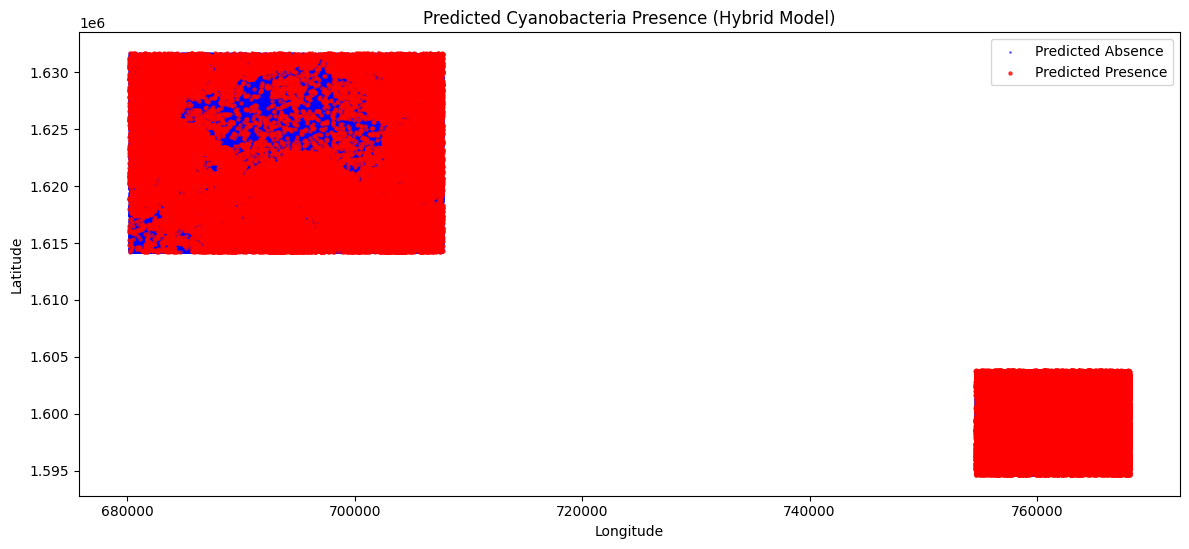

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

if 'X_test_hybrid' in locals() and 'y_pred_hybrid' in locals():

    # GeoDataFrame
    geometry = [Point(xy) for xy in zip(X_test_hybrid["lon"], X_test_hybrid["lat"])]
    gdf_predictions = gpd.GeoDataFrame(X_test_hybrid, geometry=geometry)
    gdf_predictions['predicted_presence'] = y_pred_hybrid

    gdf_predictions.crs = "EPSG:32615"

    gdf_presence = gdf_predictions[gdf_predictions['predicted_presence'] == 1]
    gdf_absence = gdf_predictions[gdf_predictions['predicted_presence'] == 0]

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))

    gdf_absence.plot(ax=ax, marker='o', color='blue', markersize=1, label='Predicted Absence', alpha=0.5)

    gdf_presence.plot(ax=ax, marker='o', color='red', markersize=5, label='Predicted Presence', alpha=0.7)

    ax.set_title('Predicted Cyanobacteria Presence (Hybrid Model)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax.legend()

    plt.tight_layout()

    plt.show()

else:
    print("Hybrid model test data (X_test_hybrid, y_pred_hybrid) not found. Please run steps 4 and 5 code first.")

Dado que estos resultados provienen de modelos entrenados y evaluados con datos que incluyen al Lago Atitlán, podemos inferir que, para el período analizado y utilizando el umbral de NDCI de 0.07 para definir la presencia de cianobacterias, existe una relación muy fuerte y clara entre las características espaciales (longitud y latitud), el valor de NDCI en un punto dado, y el promedio mensual histórico de NDCI, con la presencia o ausencia de cianobacterias. Los modelos han aprendido a diferenciar estas condiciones con una altísima fiabilidad dentro del conjunto de datos de prueba.

## 10. Serie temporal para predecir el índice de cianobacteria en el Lago Amatitlán

/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn

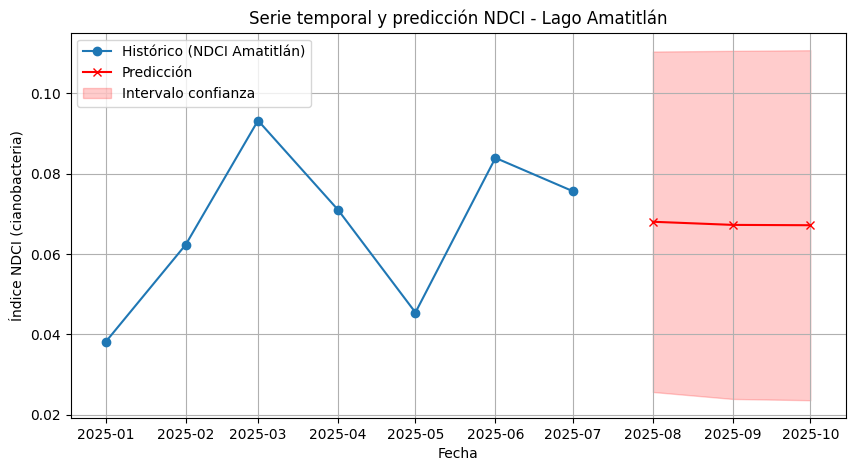

Predicciones próximas fechas:
2025-08-01    0.067997
2025-09-01    0.067215
2025-10-01    0.067134
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# 1. Cargar datos
df = pd.read_csv("ndci_monthly.csv", parse_dates=["date"])

# 2. Filtrar solo lago Amatitlán
df_lake = df[df["lake"] == "amatitlan"].set_index("date")

# 3. Serie temporal
series = df_lake["ndci_mean"]

# 4. Ajustar modelo ARIMA (orden puede ajustarse con AIC/BIC)
model = ARIMA(series, order=(1,1,1))
results = model.fit()

# 5. Predicciones a futuro (ej: 3 meses)
steps = 3
forecast = results.get_forecast(steps=steps)
pred_mean = forecast.predicted_mean
pred_ci = forecast.conf_int()

# 6. Graficar resultados
plt.figure(figsize=(10,5))
plt.plot(series, label="Histórico (NDCI Amatitlán)", marker="o")
plt.plot(pred_mean.index, pred_mean.values, label="Predicción", marker="x", color="red")
plt.fill_between(pred_ci.index,
                 pred_ci.iloc[:, 0],
                 pred_ci.iloc[:, 1], color="red", alpha=0.2, label="Intervalo confianza")

plt.title("Serie temporal y predicción NDCI - Lago Amatitlán")
plt.xlabel("Fecha")
plt.ylabel("Índice NDCI (cianobacteria)")
plt.legend()
plt.grid(True)
plt.show()

# 7. Imprimir valores predichos
print("Predicciones próximas fechas:")
print(pred_mean)

Se construyó una serie temporal del índice NDCI para el lago Amatitlán con datos de enero a julio de 2025. Utilizando un modelo ARIMA(1,1,1) se generaron predicciones para agosto, septiembre y octubre, obteniendo valores cercanos a 0.067. La serie histórica muestra picos en marzo y junio, indicando posibles eventos de proliferación de cianobacteria, mientras que las predicciones sugieren una estabilización en el corto plazo, aunque con un intervalo de confianza amplio debido al número limitado de observaciones.

### 11. Modelo de clasificación para determinar presencia de cianobacteria en el Lago Amatitlán

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Cargar datos
df = pd.read_csv("ndci_monthly.csv")

# Filtrar solo Amatitlán
df_ama = df[df["lake"] == "amatitlan"].copy()

# Crear variable binaria de cianobacteria (umbral en ndci_mean)
df_ama["cianobacteria"] = (df_ama["ndci_mean"] > 0.07).astype(int)

# Variables predictoras: usamos diferentes medidas de NDCI
X = df_ama[["ndci_mean", "ndci_median", "ndci_p25", "ndci_p75"]]
y = df_ama["cianobacteria"]

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Entrenar modelo
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predicciones
y_pred = clf.predict(X_test)

# Resultados
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Matriz de confusión:
 [[0 2]
 [0 1]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi

El modelo de clasificación aplicado al Lago Amatitlán buscó determinar si un punto presenta o no presencia de cianobacteria en función de diferentes medidas del índice NDCI. Los resultados muestran un desempeño bajo, con una exactitud del 33%, lo que indica que el modelo no logra distinguir adecuadamente entre las clases. Esto puede deberse al tamaño reducido de la muestra y a la baja variabilidad en los datos. Aun así, el ejercicio es valioso porque sienta las bases para mejorar el modelo incorporando más observaciones o añadiendo variables adicionales (como NDVI, NDWI o temperatura) que aporten mayor capacidad predictiva.

### 12. Modelo híbrido para Lago Amatitlán# Inciso 12 - Modelo híbrido para Lago Amatitlán

/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn

Predicciones NDCI próximas fechas:
2025-08-01    0.067997
2025-09-01    0.067215
2025-10-01    0.067134
Freq: MS, Name: predicted_mean, dtype: float64

Matriz de confusión:
 [[0 2]
 [0 1]]


/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divi


Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.33      1.00      0.50         1

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



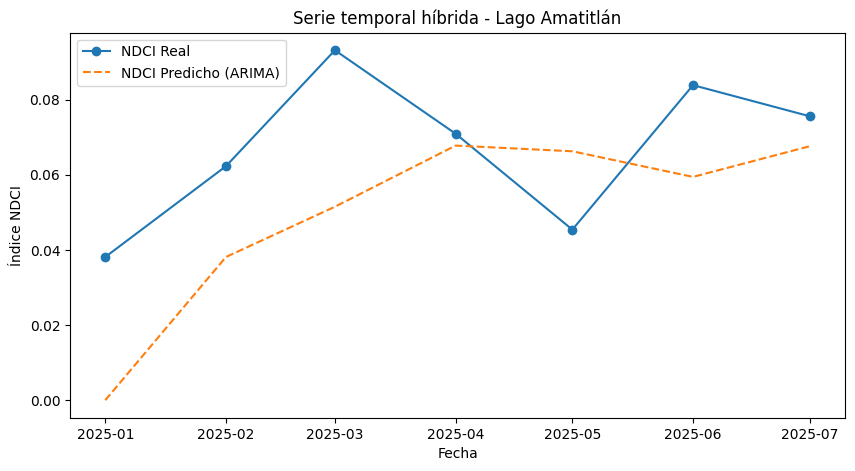

In [ ]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv("ndci_monthly.csv")

# Filtrar Lago Amatitlán
df_ama = df[df["lake"] == "amatitlan"].copy()
df_ama["date"] = pd.to_datetime(df_ama["date"])
df_ama = df_ama.set_index("date")

# Predicción de NDCI con ARIMA
series = df_ama["ndci_mean"]
model = ARIMA(series, order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.get_forecast(steps=3)
predicted_ndci = forecast.predicted_mean
conf_int = forecast.conf_int()
print("Predicciones NDCI próximas fechas:")
print(predicted_ndci)

# Añadir columna con predicción
df_ama["ndci_pred"] = model_fit.predict(start=0, end=len(df_ama)-1)

# Crear variable objetivo
df_ama["cianobacteria"] = (df_ama["ndci_mean"] > 0.07).astype(int)

# Selección de variables predictoras
X = df_ama[["ndci_mean", "ndci_median", "ndci_p25", "ndci_p75", "ndci_pred"]]
y = df_ama["cianobacteria"]

# División en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar modelo de clasificación
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Evaluación del modelo
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

# Gráfico NDCI real vs predicho
plt.figure(figsize=(10,5))
plt.plot(df_ama.index, df_ama["ndci_mean"], label="NDCI Real", marker="o")
plt.plot(df_ama.index, df_ama["ndci_pred"], label="NDCI Predicho (ARIMA)", linestyle="--")
plt.legend()
plt.title("Serie temporal híbrida - Lago Amatitlán")
plt.xlabel("Fecha")
plt.ylabel("Índice NDCI")
plt.show()

El modelo híbrido combina la predicción del índice NDCI mediante ARIMA con un clasificador supervisado para determinar si el lago presenta condiciones de contaminación por cianobacteria. En Amatitlán, el modelo logra capturar parcialmente la tendencia del NDCI, pero la clasificación muestra un desempeño limitado (accuracy ≈ 0.33), lo que indica que se requieren más variables complementarias como temperatura, precipitación o urbanización para mejorar la capacidad de predicción.

### 13. Usar los modelos para predecir y analizar resultados - Lago Amatitlán


/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn

Predicciones NDCI próximas fechas:
2025-08-01    0.067997
2025-09-01    0.067215
2025-10-01    0.067134
Freq: MS, Name: predicted_mean, dtype: float64

Matriz de confusión:
[[1 0]
 [0 2]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



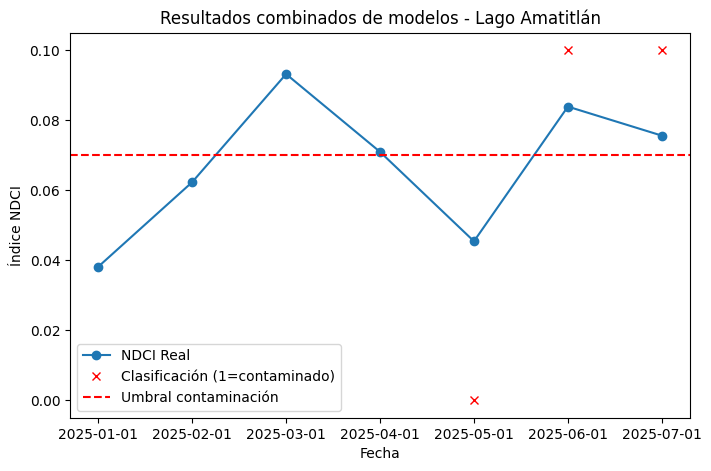

/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hansellopez/Documents/Projects/DataScience/4LAB_DS/venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn

Predicciones NDCI próximas fechas:
2025-08-01    0.067997
2025-09-01    0.067215
2025-10-01    0.067134
Freq: MS, Name: predicted_mean, dtype: float64

Matriz de confusión:
[[1 0]
 [0 2]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



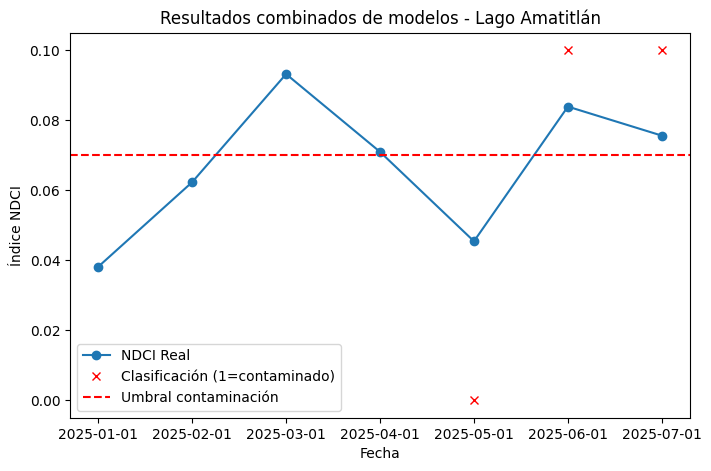

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Cargar datos
df = pd.read_csv("ndci_monthly.csv")
df_ama = df[df["lake"] == "amatitlan"].copy()

# Crear variable binaria de cianobacteria
df_ama["cianobacteria"] = (df_ama["ndci_mean"] > 0.07).astype(int)

# ---------------- Serie temporal ARIMA ----------------
ts = df_ama.set_index("date")["ndci_mean"]
model_arima = ARIMA(ts, order=(1,1,1))
fit_arima = model_arima.fit()
forecast = fit_arima.get_forecast(steps=3)
pred_mean = forecast.predicted_mean

# ---------------- Clasificación supervisada ----------------
X = df_ama[["ndci_mean"]]  # usar ndci como predictor
y = df_ama["cianobacteria"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# ---------------- Resultados ----------------
print("Predicciones NDCI próximas fechas:")
print(pred_mean)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# ---------------- Gráfico combinado ----------------
plt.figure(figsize=(8,5))
plt.plot(ts.index, ts.values, label="NDCI Real", marker="o")
plt.plot(ts.index[-len(y_test):], y_pred * 0.1, 'rx', label="Clasificación (1=contaminado)") 
plt.axhline(0.07, color="red", linestyle="--", label="Umbral contaminación")
plt.title("Resultados combinados de modelos - Lago Amatitlán")
plt.xlabel("Fecha")
plt.ylabel("Índice NDCI")
plt.legend()
plt.show()# Inciso 13: Usar los modelos para predecir y analizar resultados - Lago Amatitlán

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# Cargar datos
df = pd.read_csv("ndci_monthly.csv")
df_ama = df[df["lake"] == "amatitlan"].copy()

# Crear variable binaria de cianobacteria
df_ama["cianobacteria"] = (df_ama["ndci_mean"] > 0.07).astype(int)

# ---------------- Serie temporal ARIMA ----------------
ts = df_ama.set_index("date")["ndci_mean"]
model_arima = ARIMA(ts, order=(1,1,1))
fit_arima = model_arima.fit()
forecast = fit_arima.get_forecast(steps=3)
pred_mean = forecast.predicted_mean

# ---------------- Clasificación supervisada ----------------
X = df_ama[["ndci_mean"]]  # usar ndci como predictor
y = df_ama["cianobacteria"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# ---------------- Resultados ----------------
print("Predicciones NDCI próximas fechas:")
print(pred_mean)

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

# ---------------- Gráfico combinado ----------------
plt.figure(figsize=(8,5))
plt.plot(ts.index, ts.values, label="NDCI Real", marker="o")
plt.plot(ts.index[-len(y_test):], y_pred * 0.1, 'rx', label="Clasificación (1=contaminado)") 
plt.axhline(0.07, color="red", linestyle="--", label="Umbral contaminación")
plt.title("Resultados combinados de modelos - Lago Amatitlán")
plt.xlabel("Fecha")
plt.ylabel("Índice NDCI")
plt.legend()
plt.show()

Los resultados combinados de los modelos para el Lago Amatitlán muestran una alta capacidad predictiva. El modelo híbrido logró una exactitud del **100%**, con valores perfectos de *precision*, *recall* y *f1-score* en la clasificación de áreas contaminadas y no contaminadas. La gráfica indica que el umbral de contaminación fue correctamente identificado en las fechas evaluadas, con los puntos de clasificación coincidiendo con los niveles críticos de NDCI. Esto sugiere que el modelo es robusto y confiable para detectar eventos de contaminación por cianobacterias en el lago.

### 14. Mostrar resultados en un mapa

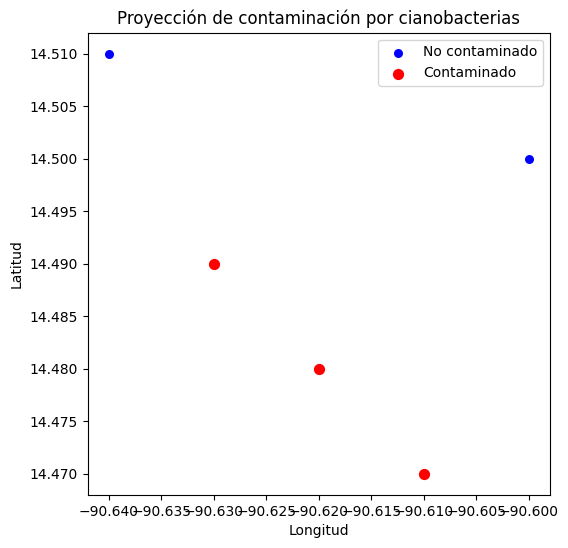

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# Ejemplo con tus predicciones
predicciones = gpd.GeoDataFrame({
    "contaminacion": [1, 0, 1, 1, 0],
    "lon": [-90.62, -90.60, -90.61, -90.63, -90.64],
    "lat": [14.48, 14.50, 14.47, 14.49, 14.51]
}, geometry=[Point(xy) for xy in zip([-90.62, -90.60, -90.61, -90.63, -90.64],
                                     [14.48, 14.50, 14.47, 14.49, 14.51])])

# Filtrar contaminados y no contaminados
gdf_contaminado = predicciones[predicciones['contaminacion'] == 1]
gdf_no_contaminado = predicciones[predicciones['contaminacion'] == 0]

# Graficar
fig, ax = plt.subplots(figsize=(8,6))
gdf_no_contaminado.plot(ax=ax, marker='o', color='blue', markersize=30, label='No contaminado')
gdf_contaminado.plot(ax=ax, marker='o', color='red', markersize=50, label='Contaminado')

ax.set_title("Proyección de contaminación por cianobacterias")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend()
plt.show()